In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the cleaned sales dataset

df = pd.read_csv("Cleaned_Sales_Dataset.csv")

In [3]:
# Display first five rows

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group,Month
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Adult,February
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior,October
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior,May
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior,December
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Middle Age,November


In [4]:
# Group data by customer

customer_data = df.groupby('Customer_ID').agg({
    'Total_Sales':'sum',
    'Quantity':'sum',
    'Order_ID':'count'
}).reset_index()

customer_data.columns = [
    'Customer_ID',
    'Total_Spend',
    'Total_Quantity',
    'Total_Orders'
]

customer_data.head()

,Customer_ID,Total_Spend,Total_Quantity,Total_Orders
0,CUST1004,8321.54,2,1
1,CUST1017,264230.68,7,1
2,CUST1026,164965.29,7,1
3,CUST1032,146990.90,7,1
4,CUST1038,37068.40,5,1


In [5]:
# Select features for clustering

X = customer_data[['Total_Spend',
                   'Total_Quantity',
                   'Total_Orders']]

X.head()

,Total_Spend,Total_Quantity,Total_Orders
0,8321.54,2,1
1,264230.68,7,1
2,164965.29,7,1
3,146990.90,7,1
4,37068.40,5,1


In [6]:
# Scale the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
# Find optimal number of clusters

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

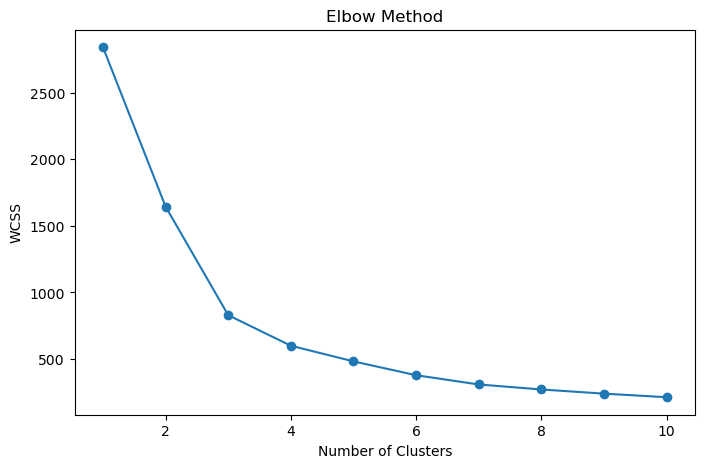

In [8]:
# Plot Elbow Method graph

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [9]:
# Train K-Means with 3 clusters

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_data['Cluster'] = kmeans.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [10]:
# Display clustered customer data

customer_data.head()

,Customer_ID,Total_Spend,Total_Quantity,Total_Orders,Cluster
0,CUST1004,8321.54,2,1,0
1,CUST1017,264230.68,7,1,1
2,CUST1026,164965.29,7,1,1
3,CUST1032,146990.90,7,1,1
4,CUST1038,37068.40,5,1,0


In [11]:
# Calculate average values for each cluster

cluster_summary = customer_data.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,Total_Spend,Total_Quantity,Total_Orders
Cluster,,,
0,68478.899314,3.539048,1.000000
1,235876.259378,8.056757,1.000000
2,311034.645000,11.461538,2.019231


In [12]:
# Count customers in each cluster

customer_data['Cluster'].value_counts()

Cluster
0    525
1    370
2     52
Name: count, dtype: int64

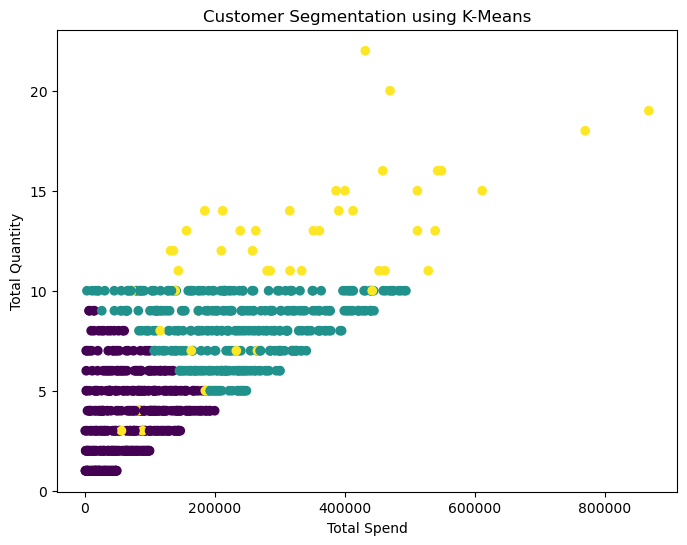

In [13]:
# Visualize customer clusters

plt.figure(figsize=(8,6))

plt.scatter(
    customer_data['Total_Spend'],
    customer_data['Total_Quantity'],
    c=customer_data['Cluster']
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Total Spend")

plt.ylabel("Total Quantity")

plt.show()